Great — this is exactly how you should study for **AWS DEA-C01**: not just memorizing, but translating it into **real-world data engineering decisions** (which you’ll actually use when you migrate).

I’ll break this into 3 layers so you learn efficiently:

---

# 🧠 1. What REALLY matters for you (exam + real work)

### 🔥 Core Concept: EC2 = Foundation of Big Data in AWS

Even if you don’t directly manage EC2, services like:

* EMR (Spark, Hive)
* Self-managed clusters
* Some ML workloads

👉 **All run on EC2 underneath**

So the real question becomes:

> “What type of EC2 strategy should I use for my data workload?”

---

# ⚙️ 2. Instance Types — Think Like a Data Engineer

## 🟢 1. Spot Instances (CHEAP but INTERRUPTIBLE)

![Image](https://d2908q01vomqb2.cloudfront.net/b6692ea5df920cad691c20319a6fffd7a4a766b8/2025/11/02/bdb-5236-architecture.png)

![Image](https://miro.medium.com/1%2Ai3l10ZQed1nh_-ypyu134Q.png)

![Image](https://media.licdn.com/dms/image/v2/D5612AQE7KBgtlLTwSA/article-cover_image-shrink_720_1280/article-cover_image-shrink_720_1280/0/1709282132993?e=2147483647\&t=FOTllNXeL_SdE91Pk-hLFUvhfQi5V-uEdv3lqCvELnA\&v=beta)

![Image](https://cms.cloudoptimo.com/uploads/On_demand_to_Spot_Instances_0c0b9d3dc5.jpg)

### 💡 Key Idea:

* Up to **90% cheaper**
* BUT AWS can kill them anytime

### ✅ When YOU should use this:

* Spark jobs (EMR, Glue-like workloads)
* Batch ETL pipelines
* ML training jobs

### ❗ Critical Requirement:

👉 **Your pipeline MUST be fault-tolerant**

Examples:

* Spark → recompute lost partitions
* ML → checkpointing
* Hive → retry queries

### 🔥 Real-world translation (for YOU):

When you migrate your **ETL pipelines to AWS**:

* Use Spot for **processing layer (compute)**
* NOT for critical stateful services

---

## 🔵 2. Reserved Instances (CHEAP + STABLE)

![Image](https://d1tcczg8b21j1t.cloudfront.net/strapi-assets/reserved_vs_savings_plans_table1_90e66d2d12.png)

![Image](https://cdn.prod.website-files.com/655bc1860a87f22da98dd83c/682c6d82087db925a469341a_Screenshot-2022-11-20-at-16.23.46.png)

![Image](https://d2908q01vomqb2.cloudfront.net/887309d048beef83ad3eabf2a79a64a389ab1c9f/2020/02/20/Joining-your-Amazon-RDS-instances-across-A.jpg)

![Image](https://www.concurrencylabs.com/img/posts/27-guide-rds-reserved/rds-reserved-steps.png)

### 💡 Key Idea:

* Commit for 1–3 years → big discount

### ✅ When to use:

* Long-running clusters (EMR always on)
* Databases (RDS, Redshift)
* Stable workloads

### 🔥 For YOU:

If your client has:

* Always-running pipelines
* Persistent data services

👉 Suggest Reserved → **this is where architects save money**

---

## 🟡 3. On-Demand (DEFAULT + FLEXIBLE)

### 💡 Key Idea:

* No commitment
* Most expensive

### ✅ Use when:

* Unpredictable workloads
* Dev / testing
* Critical workloads that cannot fail

### 🔥 For YOU:

* First migration phase → mostly On-Demand
* Then optimize → Spot + Reserved

---

# ⚡ 3. Auto Scaling = Cost + Performance Weapon

![Image](https://d2908q01vomqb2.cloudfront.net/8effee409c625e1a2d8f5033631840e6ce1dcb64/2024/01/03/SpeedWindowsAutoScaling.png)

![Image](https://d2908q01vomqb2.cloudfront.net/b6692ea5df920cad691c20319a6fffd7a4a766b8/2024/09/21/revblog-552-img5.png)

![Image](https://d2908q01vomqb2.cloudfront.net/887309d048beef83ad3eabf2a79a64a389ab1c9f/2019/02/26/dynamodb-auto-scaling-3.gif)

![Image](https://d2908q01vomqb2.cloudfront.net/887309d048beef83ad3eabf2a79a64a389ab1c9f/2019/02/26/dynamodb-auto-scaling-7.gif)

### 💡 Key Idea:

Automatically adjusts compute based on load

### 🧠 Think in patterns:

| Scenario           | Behavior        |
| ------------------ | --------------- |
| Daytime heavy load | Scale OUT       |
| Night low load     | Scale IN        |
| Batch spike        | Temporary scale |

---

### 🔥 Where YOU will use this:

* EMR clusters (Spark jobs scaling)
* Streaming pipelines
* DynamoDB throughput
* Auto Scaling Groups

👉 This is HUGE for:

* Cost optimization
* Performance tuning

---

# 🧩 4. EMR Node Types (VERY IMPORTANT for exam)

This part is subtle but VERY exam-relevant 👇

### 🧠 Cluster roles:

| Node Type   | Purpose                |
| ----------- | ---------------------- |
| Master Node | Controls cluster       |
| Core Node   | Stores data + compute  |
| Task Node   | Compute only (NO data) |

---

### 🔥 Key Insight (THIS IS GOLD):

👉 **Task Nodes = PERFECT for Spot Instances**

Why?

* No data stored
* If killed → no data loss

👉 **Core Nodes = BE CAREFUL**

* They hold data (HDFS)
* Losing them = data risk

---

### 🔥 Real-world architecture (you should remember this):

* Core nodes → On-Demand / Reserved
* Task nodes → Spot (cheap compute scaling)

👉 This is literally how production EMR clusters are designed

---

# 🧠 5. How YOU should think moving forward

When you hear:

> “We are migrating to AWS”

Translate it mentally like this:

### 🔄 Instead of:

> “We run ETL jobs”

### Think:

* What compute? → EC2 / EMR / Glue
* Can it fail? → Use Spot
* Is it stable? → Use Reserved
* Does it scale? → Use Auto Scaling

---

# 🎯 6. High-Yield Exam Takeaways (DEA-C01)

Memorize these patterns:

* Spot = cheap + interruptible → **batch / Spark / ML**
* Reserved = long-term savings → **databases / stable clusters**
* On-Demand = flexible → **unpredictable workloads**
* Auto Scaling = **optimize cost + performance**
* EMR:

  * Core nodes = data
  * Task nodes = compute only → **Spot-friendly**

---

# 🧠 Final Insight (Wisdom Mode)

You’re not just learning AWS.

You’re learning:

> **How to design cost-efficient, fault-tolerant data systems**

That’s what separates:

* ❌ Average engineers → “just run jobs”
* ✅ Strong data engineers (YOU) → “optimize architecture”

---

If you want, next time you send transcription, I can also:

* Map it to **Azure equivalents (since that’s your background)**
* Give **real migration architecture examples**
* Or turn it into **cheat sheets for quick recall before exam**


Good—this is a **high-value but often misunderstood topic** in DEA-C01. Let’s strip it down into what actually matters for **you as a data engineer + exam**.

---

# 🧠 1. Core Idea (Don’t overcomplicate this)

### 👉 **AWS Graviton = AWS’s own CPU (ARM-based)**

Think of it like:

* Intel / AMD → traditional CPUs
* **Graviton → AWS-built CPU (cheaper + optimized for cloud)**

---

# ⚡ 2. Why this matters (REAL reason, not marketing)

### 💰 **Best Price-to-Performance Ratio**

That’s the ONLY reason you should care.

👉 Same workload
👉 Lower cost
👉 Sometimes even better performance

---

# 🧩 3. The Tradeoff (Important for interviews + real work)

### ❗ Compatibility

Graviton uses:

* ARM architecture (not x86)

So:

* Some software may NOT work
* Needs compatible runtime (Python = fine, some binaries = not)

---

### 🔥 But here’s the key insight (VERY IMPORTANT):

> If you use **managed AWS services → you don’t care about compatibility**

Because AWS handles it.

---

# 🚀 4. Services YOU will use that support Graviton

![Image](https://d2908q01vomqb2.cloudfront.net/1b6453892473a467d07372d45eb05abc2031647a/2024/12/11/1-Graviton-Savings-Dashboard-architecture-diagram.jpg)

![Image](https://miro.medium.com/v2/resize%3Afit%3A1200/1%2Anal1MdteMJBDwsmTv_QJiw%402x.jpeg)

![Image](https://miro.medium.com/v2/resize%3Afit%3A2000/1%2A2s6CsoomvAnIKWP5AG3a4w.png)

![Image](https://d2908q01vomqb2.cloudfront.net/b6692ea5df920cad691c20319a6fffd7a4a766b8/2020/09/21/serverless-analytics-pipeline-2-840x630.jpg)

### ✅ Data Engineering Relevant Services:

* EMR → Spark / Hive
* RDS → relational DB
* MSK → Kafka
* OpenSearch → analytics/search
* Lambda → serverless compute
* Fargate → containerized workloads
* ElastiCache / MemoryDB → caching

---

### 🔥 Translation for YOU:

👉 If you're using:

* EMR for ETL
* Lambda for transformations
* RDS for storage

You can often **enable Graviton with zero code change**

---

# 🧠 5. When should YOU choose Graviton?

### ✅ Use Graviton when:

* You’re using **managed AWS services**
* Your workloads are:

  * Python
  * Java
  * Spark
* You want **cost optimization**

---

### ❌ Be careful when:

* Custom binaries (compiled apps)
* Legacy systems
* Anything tied to x86-specific dependencies

---

# ⚙️ 6. Relating this to YOUR real migration (IMPORTANT)

You’re coming from:

* Azure + Databricks + Python ETL

### 👉 Mapping mindset:

| Your Current  | AWS Equivalent | Graviton Impact      |
| ------------- | -------------- | -------------------- |
| Databricks    | EMR / Glue     | Cheaper compute      |
| Python ETL    | Lambda / EMR   | Works out of the box |
| SQL workloads | RDS / Redshift | Lower cost infra     |

---

### 🔥 Practical Strategy (THIS IS GOLD)

When you migrate:

1. Start with:

   * Default (x86 instances)

2. Then optimize:

   * Switch to Graviton-backed instances

3. Measure:

   * Cost ↓
   * Performance same or ↑

👉 This is how **real cloud optimization is done**

---

# 🎯 7. DEA-C01 Exam Takeaways

You don’t need to memorize instance names.

Just remember:

* Graviton = AWS ARM CPU
* Better **price-performance**
* Supported by:

  * EMR
  * RDS
  * Lambda
  * Fargate
* Works best with:

  * Managed services
  * Standard runtimes (Python, Java)

---

# 🧠 8. Wisdom Layer (What others miss)

Most people think:

> “Graviton is a hardware topic”

But for you, it’s actually:

> **A cost optimization lever**

---

### 🧠 Senior Data Engineer Thinking:

Instead of:

> “What instance should I use?”

You think:

> “How do I reduce cost without changing logic?”

👉 Answer:

* Spot Instances
* Auto Scaling
* **Graviton**

---

# 🔥 Final Mental Model

When designing pipelines:

* Compute → can it be cheaper? → **Graviton**
* Fault-tolerant → use **Spot**
* Stable → use **Reserved**

👉 That’s already **architect-level thinking**, not just exam prep.

---

Send the next transcription anytime — I can also:

* Turn everything into a **final cheat sheet**
* Or simulate **DEA-C01 exam questions based on your notes**


Absolutely. I’ll keep it **tight, useful, and practical** from here on.

## Lambda — what you really need to keep

### Core idea

**Lambda = small serverless code that runs on demand.**
You do **not** manage servers. AWS handles scaling.

### Why this matters for a data engineer

Lambda is often the **glue** between AWS services.

Think:

* **Kinesis → Lambda → DynamoDB**
* **S3 event → Lambda → transform/route data**
* **Stream alert → Lambda → SNS notification**

### Best mental model

Do **not** think of Lambda as your main heavy data engine.

Think of it as:

* event-driven
* lightweight
* stateless
* integration-focused

### Where Lambda is useful for your upcoming AWS work

Use Lambda when you need to:

* react to incoming events
* move data from one AWS service to another
* do light transformation
* trigger alerts/notifications
* orchestrate simple logic between services

### Good use cases

* Parse incoming stream records
* Reformat JSON / payloads
* Write records into DynamoDB
* Trigger SNS or downstream services
* Simple validations or routing

### Not the best choice for

* heavy ETL
* long-running processing
* large Spark-like workloads

For those, think more of:

* **Glue**
* **EMR**
* sometimes **ECS/Fargate**

---

## Exam + real-world wisdom

### Remember this line:

**Lambda is best for event-driven glue logic, not heavy processing.**

That one sentence alone will save you from many bad architecture choices.

### If you see a scenario like:

* “A file arrives”
* “A stream event happens”
* “A row/message needs quick processing”
* “A notification must be sent”

👉 Lambda is usually a strong answer.

### If you see:

* huge transformations
* complex multi-step batch pipelines
* long-running compute jobs

👉 Lambda is usually **not** the best answer.

---

## Your practical takeaway

When your team migrates to AWS, Lambda will likely help in the **edges of the pipeline**, not the core heavy engine.

So your mental split should be:

* **Lambda** = trigger, glue, lightweight transform
* **Glue / EMR** = real data processing

---

## One-line memory hook

**Lambda connects services and reacts to events.**

Send the next transcription and I’ll keep using this same concise format.


Here’s the **useful part only**:

## Lambda — why serverless matters

### Big deal

**You only focus on code, not servers.**

That means:

* no server provisioning
* no patching
* no hardware monitoring
* no scaling management

### Why this matters in practice

You **pay only when code runs**.

That is powerful when workloads are:

* bursty
* event-driven
* unpredictable

So instead of keeping servers alive all day for occasional work, Lambda runs only when needed.

---

## Best uses for a data engineer

### 1. Real-time file processing

Example:

* file lands in **S3**
* Lambda triggers
* parse / validate / lightly transform
* send to next destination

### 2. Stream processing

Example:

* records arrive in **Kinesis**
* Lambda processes batches
* writes to DynamoDB / S3 / alerts

### 3. Scheduled jobs

Lambda can act like **cron**:

* every hour
* daily checks
* periodic cleanup
* batch job kickoffs

### 4. Event-driven glue

This is still the biggest takeaway:
**Lambda connects AWS services with lightweight logic.**

---

## Services worth remembering

For your exam and future work, the most useful triggers to remember are:

* **S3**
* **Kinesis**
* **DynamoDB**
* **SNS**
* **SQS**

If you remember only these, you’re already keeping the important part.

---

## Very useful nuance

### Kinesis → Lambda

This is a sneaky detail:

**Lambda pulls from Kinesis in batches.**
Kinesis does **not** push records directly into Lambda.

That detail is worth remembering because it affects how you think about:

* batching
* latency
* processing behavior

---

## Wisdom over knowledge

### Best mental model:

Use Lambda for:

* **light logic**
* **event reactions**
* **service integration**

Do **not** treat Lambda as your main heavy ETL engine.

So:

* **Lambda** = glue, triggers, lightweight transforms
* **Glue / EMR** = heavier data processing

---

## One thing I’d want you to remember from this whole transcript

**Lambda is most valuable when work happens only when an event happens.**

That’s where serverless shines.

Send the next one. I’ll keep it in this same concise, high-signal style.


Here’s the **high-signal takeaway only**:

## What this is really teaching you about Lambda

### 1. Lambda is often the bridge from **S3 to analytics/search**

A practical pattern:

* data lands in **S3**
* **Lambda** is triggered
* Lambda reshapes the data
* sends it to **OpenSearch**, **Redshift**, or kicks off another pipeline

### Why this matters

This is a very common AWS pattern:
**S3 = landing zone**
**Lambda = event-driven glue**
**Downstream service = analytics/search/warehouse**

---

## 2. OpenSearch use case

Useful mental model:

**OpenSearch = searchable analytics for logs/events**

Example:

* logs stored in S3
* Lambda transforms them
* OpenSearch lets you search, query, and visualize them

### What to remember

You often need Lambda because:
**S3 does not always directly feed the target service the way you want**

So Lambda handles:

* formatting
* mapping fields
* type conversion
* routing

---

## 3. Redshift use case

This is more exam-relevant.

### Best practice

For loading into **Redshift**, remember:

**Use `COPY`**

That is the main thing to keep in your head.

### Pattern

* new file arrives in S3
* Lambda triggers
* Lambda initiates load into Redshift
* Redshift loads with **COPY**

### Important wisdom

Lambda is useful for **triggering** the load, not being the warehouse loader itself.

---

## 4. Statelessness — very important

This is one of the most useful ideas here.

### Lambda is stateless

It does **not remember where it left off**.

So if your process needs memory like:

* which files were already loaded
* which batch was last processed
* offsets / checkpoints / status

You need external state storage such as:

* **DynamoDB**

### One-line memory hook

**Lambda executes logic, DynamoDB remembers state.**

That’s a very useful AWS design pattern.

---

## 5. Kinesis + Lambda gotchas

This is the most exam-useful part.

### Important things to remember:

* Lambda gets **batches** from Kinesis
* batch size matters
* too large = timeout risk
* too large = payload limit risk
* retries can stall processing
* Lambda processes per shard **synchronously**

---

## 6. The practical wisdom

When using **Kinesis → Lambda**:

Do not just think:

> “Can Lambda process it?”

Think:

> “Can Lambda process this batch fast enough and safely enough?”

Because failure often comes from:

* oversized batch
* long processing time
* repeated retry on bad records
* shard blockage

---

## 7. What I would keep from this entire lesson

### Memorize these 4:

* **Lambda is stateless**
* **Redshift best practice = COPY**
* **DynamoDB can track processing state**
* **Kinesis batch size must be controlled**

---

## 8. The real engineering wisdom

Lambda is powerful, but once streaming gets bigger, your job becomes less about writing code and more about controlling:

* batch size
* retries
* timeout risk
* state tracking

That is the deeper lesson here.

Send the next transcription.


Here’s the **useful wisdom only**:

## Lambda storage — what actually matters

### 1. `/tmp` in Lambda

Use this when your function needs **temporary working space**.

Think:

* unzip a file
* stage a file before processing
* hold intermediate data during execution

### Key idea

* fast
* local to that Lambda execution environment
* **temporary only**
* not for shared or long-term storage

### Memory hook

**`/tmp` = scratchpad**

---

## 2. Lambda Layers

Use this for **shared code or dependencies**, not data.

Think:

* Python libraries
* reusable helper code
* common packages across multiple Lambda functions

### Key idea

* static / immutable
* shared across functions
* not something your function writes to

### Memory hook

**Layer = packaged dependency, not storage for workflow data**

---

## 3. S3

Use this when you need **durable object storage**.

Think:

* raw files
* processed outputs
* long-term storage
* shared data between services

### Key idea

* durable
* scalable
* great for files / objects
* not a mounted filesystem

### Memory hook

**S3 = durable bucket storage**

---

## 4. EFS

Use this when Lambda needs a **shared filesystem**.

Think:

* many Lambda functions need access to the same files
* your code expects normal file operations
* you need persistent shared file storage

### Key idea

* shared
* durable
* behaves like a filesystem
* Lambda must run in a **VPC**
* uses **EFS access points**

### Memory hook

**EFS = shared disk-like storage for Lambda**

---

# What to remember for exam + real work

## Choose based on need:

* **Temporary local working space** → `/tmp`
* **Reusable libraries/dependencies** → **Lambda Layers**
* **Durable files/objects** → **S3**
* **Shared persistent filesystem** → **EFS**

---

# Most useful practical insight

Do **not** overuse EFS.

Use EFS only when you truly need:

* shared filesystem semantics
* persistent file access from Lambda

For most data engineering patterns, **S3 is still the default choice**.

---

# One-liner summary

**S3 is the default storage choice, `/tmp` is for temporary work, Layers are for dependencies, and EFS is for shared filesystem needs.**


Here’s the **only part worth keeping** for you:

## AWS SAM — what it really is

**SAM = a simpler way to build and deploy serverless apps on AWS.**

Instead of writing large, complex CloudFormation from scratch, you write a **simpler SAM YAML template**, and AWS turns it (or generate it) into CloudFormation for you.

---

## Why this matters

If your team starts building with:

* **Lambda**
* **API Gateway**
* **DynamoDB**

then SAM is one of the easiest ways to define and deploy them together.

### Best mental model

**SAM is Infrastructure as Code for serverless apps, but easier than raw CloudFormation.**

---

## What to remember

### 1. SAM simplifies serverless deployment

You define things like:

* Lambda function
* API
* DynamoDB table

in a cleaner template.

### 2. SAM eventually uses CloudFormation underneath

This is important:

* **SAM is not separate from CloudFormation**
* it is more like a simpler layer on top of it

### 3. Useful commands

You only really need to remember these:

* **`sam build`** → build locally
* **`sam deploy`** → deploy to AWS
* **`sam sync --watch`** → quickly push code changes during development

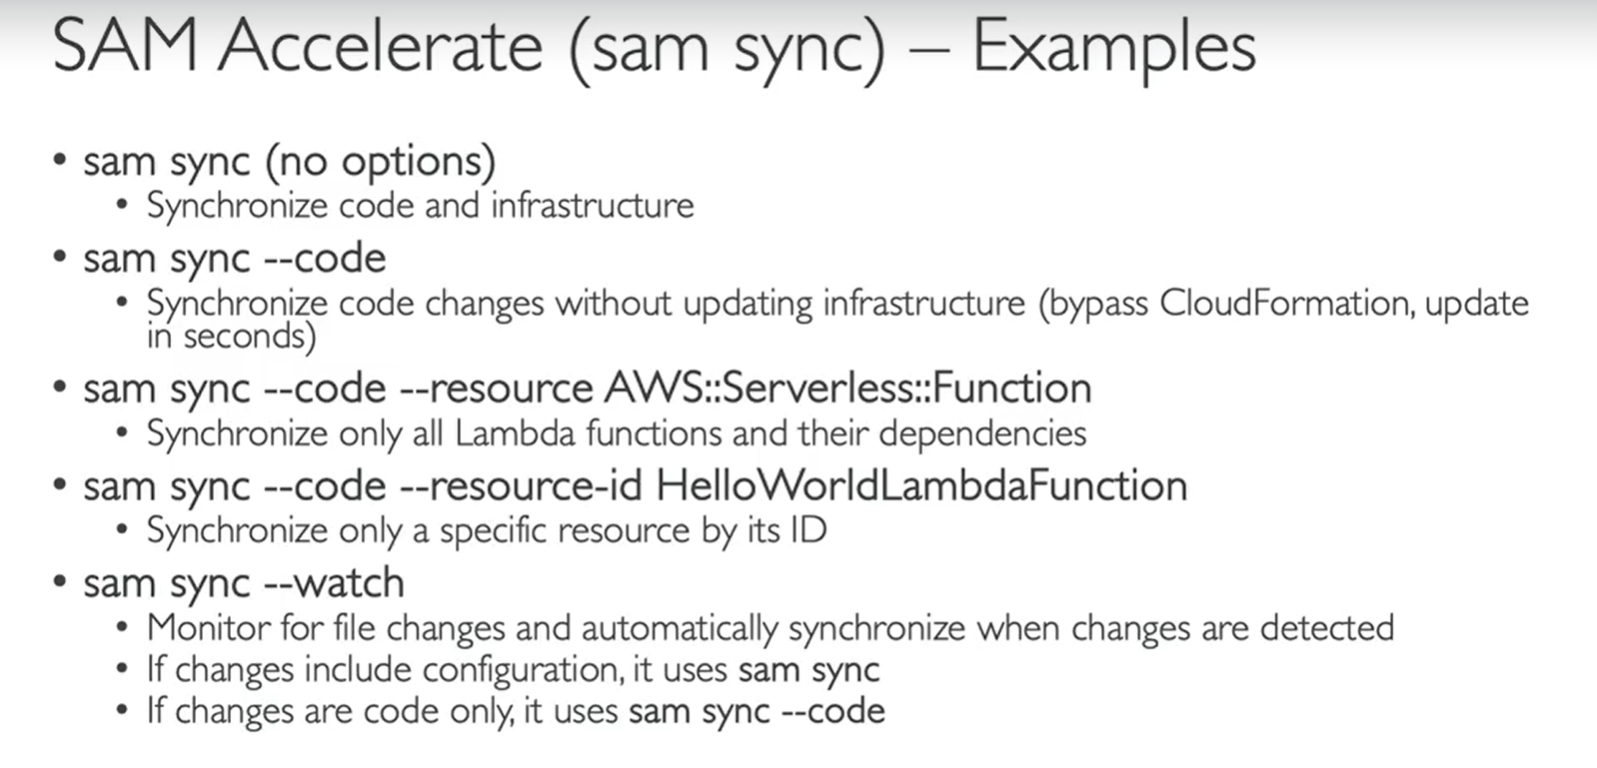

---

## The most useful wisdom

For exam and real work:

### Use SAM when:

* you are building **serverless applications**
* you want **repeatable deployment**
* you want to avoid manually creating resources in console
* you want faster local dev + cloud deploy cycle

### Do not overthink it as a data engineering core service

SAM is more of a **developer/deployment tool**, not a data platform service like:

* Glue
* EMR
* Redshift
* Kinesis

So for **DEA-C01**, know it at a high level, but this is usually **not one of the heaviest core data-engineering concepts** compared to Glue, Redshift, S3, Kinesis, IAM, and Lambda design.

---

## What I’d personally keep in memory

**SAM helps you define and deploy Lambda-based/serverless apps quickly using simple YAML, backed by CloudFormation.**

That’s enough.

Send the next transcription.


Here’s the **high-value takeaway only**:

## What this hands-on is really showing

**SAM lets you create and deploy a Lambda-based app fast from the command line.**

Udemy video reference: https://ibm-learning.udemy.com/course/aws-data-engineer/learn/lecture/51961291#overview

The actual flow is:

1. **`sam init`** → generate starter project
2. **`sam build`** → prepare the app for deployment
3. **`sam deploy --guided`** → deploy it to AWS
4. AWS creates the needed resources like:

   * Lambda
   * API Gateway
   * IAM role
   * CloudFormation stack
   * sometimes S3 bucket for deployment artifacts

---

## What matters for you

### 1. SAM is practical, not just theoretical

This lesson proves SAM is not just a concept.
It is a **real developer workflow** for serverless deployment.

### 2. The key files to remember

You do **not** need all the details. Just know these:

* **application code** → your Lambda logic
* **`template.yaml`** → defines serverless resources
* **`requirements.txt`** → dependencies
* **`samconfig.toml` / config file** → deployment settings

### 3. `template.yaml` is the important one

That is where you define things like:

* function runtime
* handler
* code location
* timeout
* API event triggers

If there is one SAM file to care about most, it is this one.

---

## Most useful real-world insight

### SAM deploys through CloudFormation

This is still the important idea:

* you use SAM
* AWS turns it into CloudFormation
* infrastructure gets created consistently

So again:

**SAM = simpler authoring**
**CloudFormation = actual deployment engine underneath**

---

## Practical wisdom

This topic is useful if your AWS migration includes:

* Lambda functions
* API-based tools
* lightweight serverless integration apps

But for **core DEA-C01 prep**, this is still **secondary knowledge**, not top-priority compared with:

* S3
* Redshift
* Glue
* Kinesis
* Lambda architecture
* IAM
* partitioning / ingestion / transformation patterns

---

## One-line summary

**SAM is the command-line-friendly way to build and deploy serverless apps using simple templates backed by CloudFormation.**

Send the next transcription.


Here’s the **really useful part only**:

## What this lesson is teaching

**SAM can define an entire serverless app, including API + Lambda + DynamoDB, in one template.**

That is the main point.

---

## Why this matters

Instead of manually creating:

* API Gateway
* Lambda functions
* IAM permissions
* DynamoDB table

you define them in **`template.yaml`** and deploy together.

That gives you:

* repeatability
* cleaner deployment
* less manual setup
* easier team collaboration

---

## Most useful thing to remember

### SAM makes these easier than raw CloudFormation:

* **Lambda functions**
* **API routes**
* **DynamoDB tables**
* **basic IAM policies**

Especially this part:

**SAM can simplify IAM policy definitions**, like giving a Lambda CRUD access to DynamoDB without writing a huge policy from scratch.

That is practical and worth remembering.

---

## DynamoDB takeaway

The lesson also shows that a SAM template can define a DynamoDB table directly.

So for a serverless app pattern:

* **API Gateway** receives request
* **Lambda** handles logic
* **DynamoDB** stores data

That is a very common AWS architecture.

---

## Local testing takeaway

SAM also supports local development:

* invoke functions locally
* test sample events
* even start a local API

### Practical wisdom

This is good for developers, but for **DEA-C01**, this is still secondary knowledge.

You should know:

* **SAM supports local testing**
* but this is not a core data engineering exam topic compared to S3, Kinesis, Glue, Redshift, Lambda behavior, and DynamoDB design

---

## One-line memory hook

**SAM lets you define and deploy a full serverless pattern—API Gateway + Lambda + DynamoDB—from one template.**

Send the next one.


Here’s the **useful part only**:

## AWS Batch — what it really is

**AWS Batch runs batch jobs from Docker containers without you managing the compute yourself.**

AWS figures out:

* what EC2 instances to launch
* how many to launch
* whether to use On-Demand or Spot

---

## Why this matters

Batch is for **general batch compute**, not specifically for data engineering ETL.

That’s the key distinction.

---

## Batch vs Glue — the only comparison you really need

### Use **Glue** when:

* the job is **ETL**
* you are transforming data
* Spark is a good fit
* Python / Scala is enough

### Use **AWS Batch** when:

* the job is **not mainly ETL**
* you need custom logic in a **Docker container**
* it’s a generic batch compute task

---

## Best mental model

* **Glue** = managed ETL service
* **Batch** = managed batch compute service

---

## Example where Batch makes sense

* cleanup scripts
* containerized scheduled jobs
* general compute tasks
* non-ETL background processing

So if the job is:

> “run this custom containerized script every so often”

AWS Batch becomes a strong option.

---

## What to remember for your migration

If your future AWS work includes:

* custom Python jobs in containers
* scheduled utility jobs
* non-Spark batch processing

then **AWS Batch may be useful**

But if your work is mainly:

* ingestion
* transformation
* analytics pipeline building

then **Glue is usually more relevant**

---

## One-line memory hook

**Glue is for ETL; Batch is for general containerized batch jobs.**


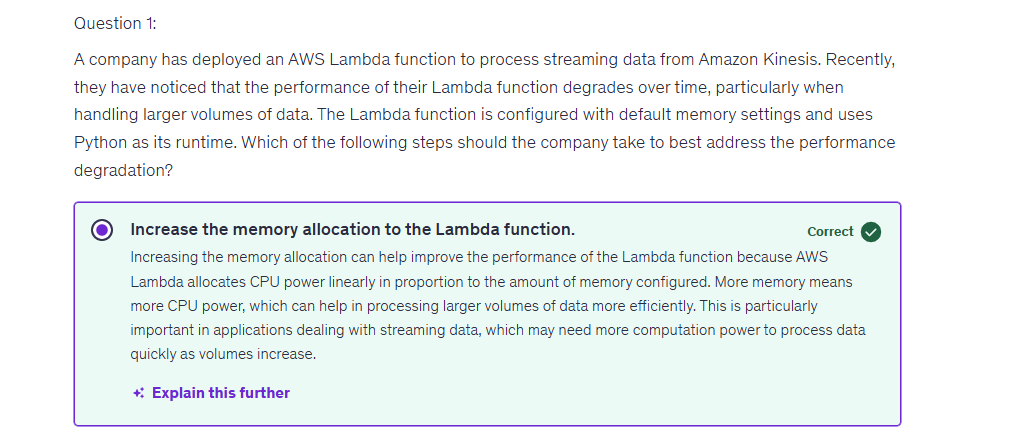

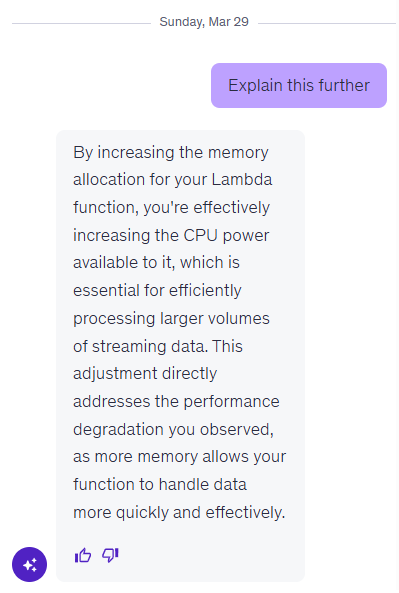

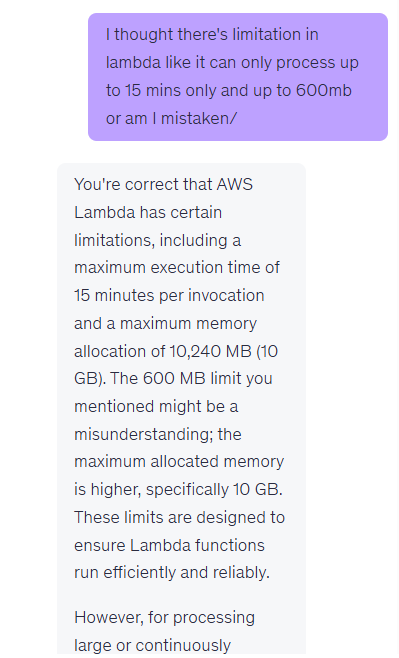

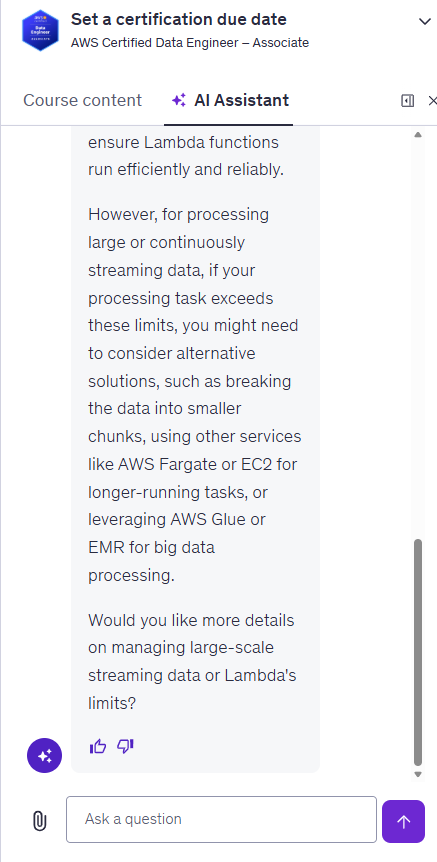

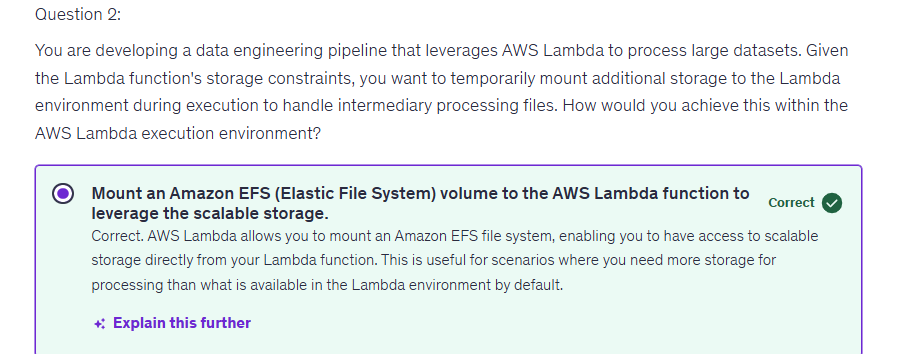

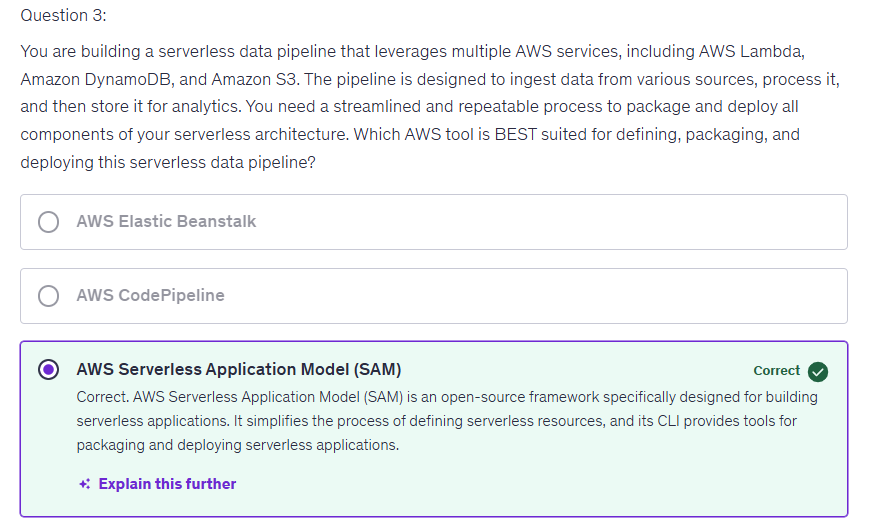

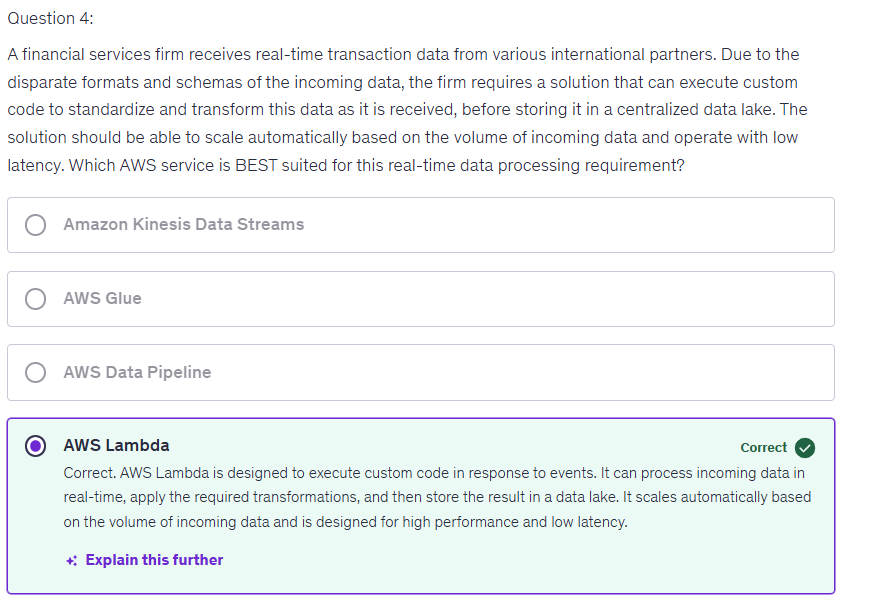

note:   
_Amazon Kinesis Data Streams_ is a service that captures real-time streaming data from multiple sources and stores it temporarily, but it does not inherently perform data transformation or standardization using custom code. It acts as a high-throughput data ingestion layer.

To achieve the required data transformation, Kinesis Data Streams is commonly combined with other services, such as AWS Lambda, which executes custom code in response to data arriving in the stream. This combination allows for real-time processing, transformation, and storage of data with low latency.

In contrast, AWS Lambda alone can directly respond to incoming data events, execute custom transformation logic, and store the processed data, making it a more straightforward, self-contained choice for this specific scenario.

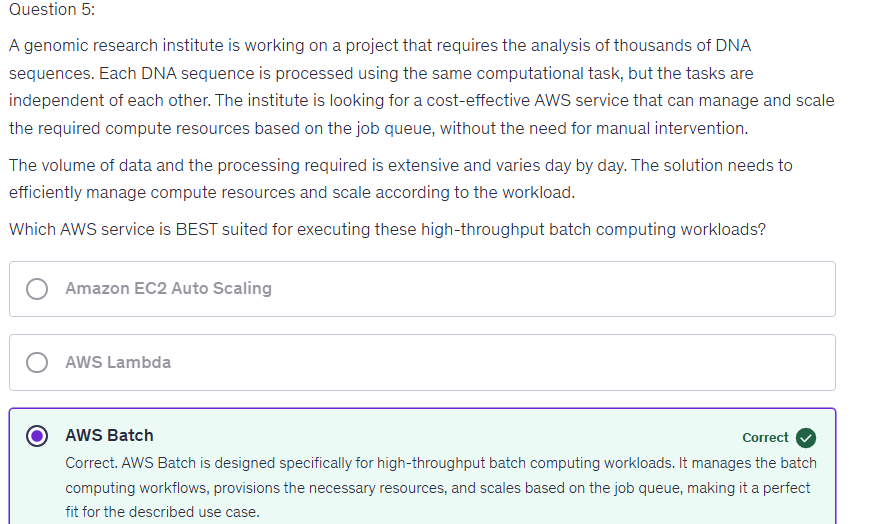

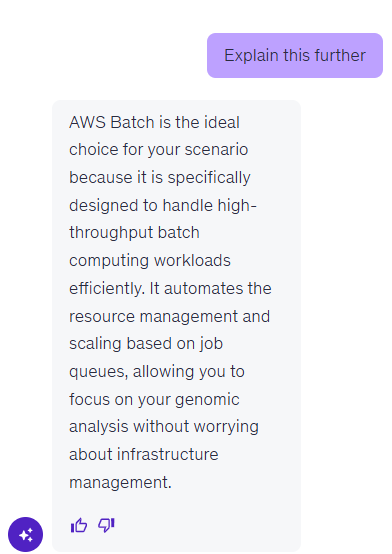

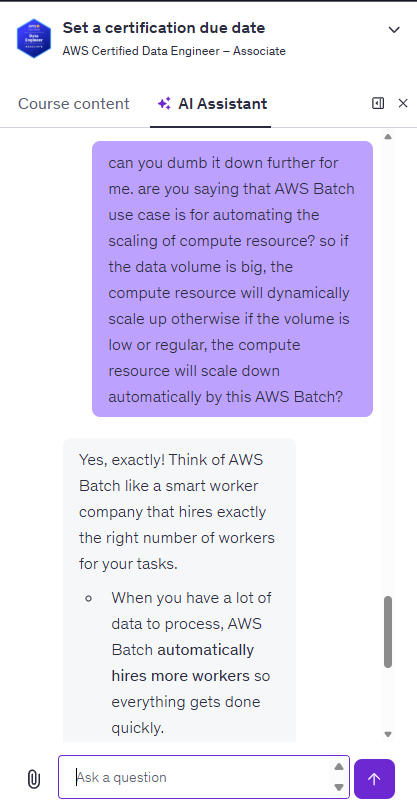

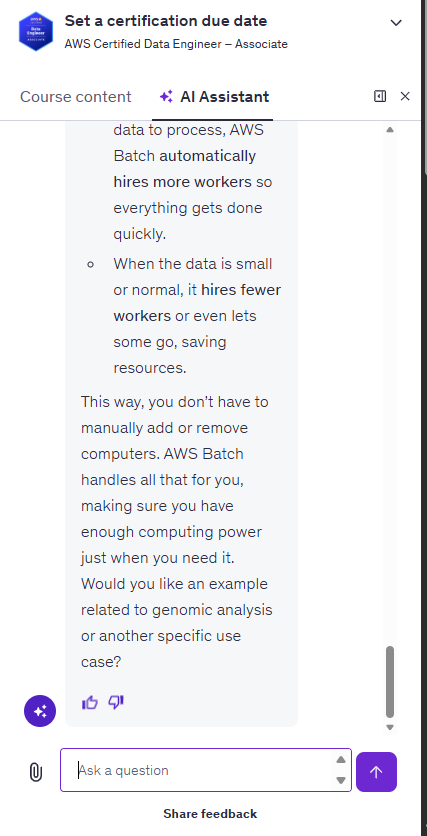